In [5]:
from datetime import date
import pandas as pd
dataset=pd.read_csv('iris.csv')
#print(dataset)
print(dataset.head(10))

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
5           5.4          3.9           1.7          0.4  setosa
6           4.6          3.4           1.4          0.3  setosa
7           5.0          3.4           1.5          0.2  setosa
8           4.4          2.9           1.4          0.2  setosa
9           4.9          3.1           1.5          0.1  setosa


In [6]:
print(dataset.describe())

       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000


In [11]:
print(dataset.species)
print(dataset.species.unique())

['setosa' 'versicolor' 'virginica']


In [13]:
X=dataset.iloc[:,:-1] #slicing
Y=dataset.iloc[:,-1]
print(X)
print(Y)

     sepal_length  sepal_width  petal_length  petal_width
0             5.1          3.5           1.4          0.2
1             4.9          3.0           1.4          0.2
2             4.7          3.2           1.3          0.2
3             4.6          3.1           1.5          0.2
4             5.0          3.6           1.4          0.2
..            ...          ...           ...          ...
145           6.7          3.0           5.2          2.3
146           6.3          2.5           5.0          1.9
147           6.5          3.0           5.2          2.0
148           6.2          3.4           5.4          2.3
149           5.9          3.0           5.1          1.8

[150 rows x 4 columns]
0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: species, Length: 150, dtype: object


In [14]:
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
Y=le.fit(Y).transform(Y)
print(Y)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=0)
print(X_train)
print(X_test)
print(y_train)
print(y_test)

     sepal_length  sepal_width  petal_length  petal_width
60            5.0          2.0           3.5          1.0
116           6.5          3.0           5.5          1.8
144           6.7          3.3           5.7          2.5
119           6.0          2.2           5.0          1.5
108           6.7          2.5           5.8          1.8
..            ...          ...           ...          ...
9             4.9          3.1           1.5          0.1
103           6.3          2.9           5.6          1.8
67            5.8          2.7           4.1          1.0
117           7.7          3.8           6.7          2.2
47            4.6          3.2           1.4          0.2

[105 rows x 4 columns]
     sepal_length  sepal_width  petal_length  petal_width
114           5.8          2.8           5.1          2.4
62            6.0          2.2           4.0          1.0
33            5.5          4.2           1.4          0.2
107           7.3          2.9           6.3    

In [ ]:
from sklearn.neural_network import MLPClassifier

clf = MLPClassifier(random_state=1, max_iter=300,hidden_layer_sizes=(30,20))
clf.fit(X_train, y_train)
clf.score(X_test, y_test)
y_pred=clf.predict(X_test)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

In [37]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(random_state=0)
clf.fit(X_train, y_train)
clf.score(X_test, y_test)

1.0

In [38]:
y_pred = clf.predict(X_test)
print(y_pred)
print(y_test)


[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0 0 0 2 1 1 0 0 1 2 2 1 2 1 2 1]
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0 0 0 2 1 1 0 0 1 2 2 1 2 1 2 1]


In [39]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[19  0  0]
 [ 0 17  0]
 [ 0  0 17]]


In [33]:
print(le.classes_)

['setosa' 'versicolor' 'virginica']


<Axes: >

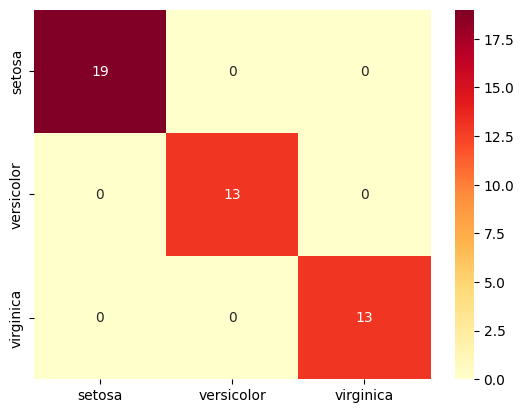

In [34]:
import seaborn as sb
sb.heatmap(cm, annot=True,xticklabels=le.classes_, yticklabels=le.classes_,cmap="YlOrRd")

In [35]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_accuracies = []

for fold, (train_index, test_index) in enumerate(kf.split(X, Y)):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = Y[train_index], Y[test_index]

    clf_cv = LogisticRegression(random_state=0, solver='liblinear') # Using liblinear solver for small datasets
    clf_cv.fit(X_train_fold, y_train_fold)
    accuracy = clf_cv.score(X_test_fold, y_test_fold)
    fold_accuracies.append(accuracy)
    print(f"Fold {fold+1} Accuracy: {accuracy:.4f}")

import numpy as np
print(f"\nAverage K-Fold Accuracy: {np.mean(fold_accuracies):.4f}")
print(f"Standard Deviation of K-Fold Accuracies: {np.std(fold_accuracies):.4f}")

In [43]:
from sklearn.model_selection import cross_val_score
import numpy as np
scores = cross_val_score(clf, X, Y, cv=5)
scores
print(np.mean(scores),np.std(scores))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9733333333333334 0.02494438257849294


In [28]:
print(le.inverse_transform(clf.predict([[5.1,3.5,1.4,0.2]])))

['setosa']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [52]:
from sklearn.svm import SVC
clf = SVC(kernel='linear',C=0.2,gamma=0.5)
clf.fit(X_train, y_train)
clf.score(X_test, y_test)

0.9777777777777777